In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
pip install geopandas matplotlib mapclassify contextily

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import mapclassify
import numpy as np
import contextily as cx

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/LOC exploitable carte .csv", sep=",")

In [ ]:
df.head()

,name,latitude,longitude,addresstype,continent,pays,etude_M1,token_val
0,Aapravasi Ghat,-20.158567,57.503109,protected_area,Afrique,Maurice,0,Aapravasi Ghat
1,Abidos,43.398175,-0.623853,village,Europe,France,0,Abidos
2,Abomey,7.182001,1.993632,city,Afrique,Bénin,0,Abomey
3,Abomey,7.182001,1.993632,city,Afrique,Bénin,0,Abomey
4,Abomey,7.182001,1.993632,city,Afrique,Bénin,0,Abomey


In [ ]:
# Re-create df1 with all original columns where 'etude_M1' is 1
df1 = df[df['etude_M1'] == 1]
display(df1.head())

,name,latitude,longitude,addresstype,continent,pays,etude_M1,token_val
268,Afrin,36.508379,36.870089,town,Asie,Syrie,1,Afrin
269,Afrin,36.508379,36.870089,town,Asie,Syrie,1,Afrin
339,Akkad,33.368169,44.496260,quarter,Asie,Irak,1,Akkad
340,Akkad,33.368169,44.496260,quarter,Asie,Irak,1,Akkad
341,Akkad,33.368169,44.496260,quarter,Asie,Irak,1,Akkad


In [ ]:
print(df1.columns)

Index(['name', 'latitude', 'longitude', 'addresstype', 'continent', 'pays',
       'etude_M1', 'token_val'],
      dtype='object')


Let's check if there are any duplicate `(latitude, longitude)` pairs in `df1` *before* the `groupby` operation.

In [ ]:
df2 = df1.groupby(by=["latitude","longitude"]).size().reset_index(name='eff')

In [ ]:
df2

,latitude,longitude,eff
0,28.129248,60.823685,1
1,28.669255,54.064155,1
2,28.669737,57.737338,3
3,28.673483,57.758065,1
4,28.957610,50.837125,1
...,...,...,...
198,37.166667,42.150000,2
199,37.198444,55.070672,10
200,38.073856,46.297287,1
201,38.073861,46.297879,16


In [ ]:
gdf = gpd.GeoDataFrame(
    df2,
    geometry=gpd.points_from_xy(df2["longitude"], df2["latitude"]),
    crs="EPSG:4326" # Set initial CRS to WGS84
).to_crs(epsg=3857) # Reproject to Web Mercator for contextily

In [ ]:
from shapely.geometry import box

In [ ]:
xmin, ymin, xmax, ymax = gdf.total_bounds

In [ ]:
sizes = (df2["eff"] ** 0.5) * 50
sizes

,eff
0,50.000000
1,50.000000
2,86.602540
3,50.000000
4,50.000000
...,...
198,70.710678
199,158.113883
200,50.000000
201,200.000000


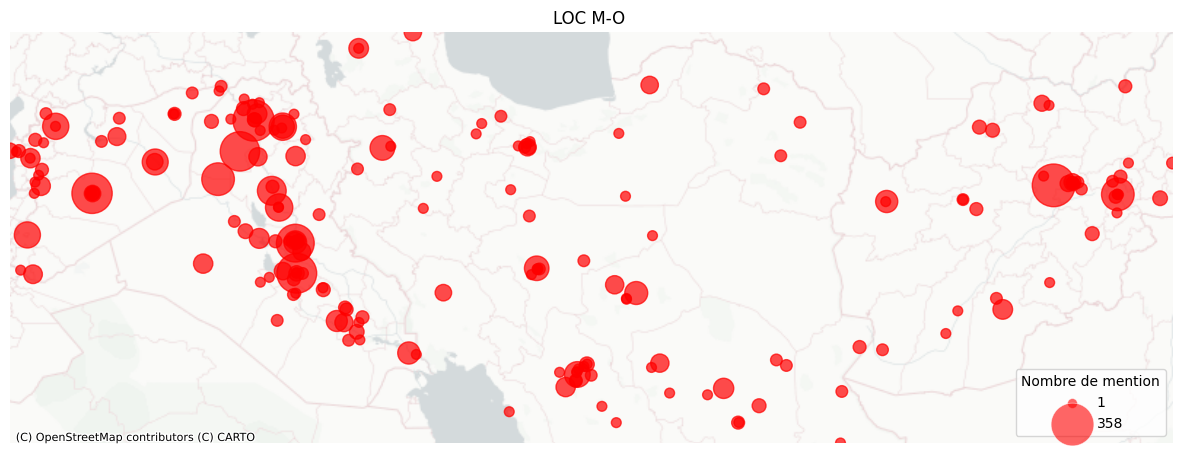

In [ ]:
fig, ax = plt.subplots(figsize=(15, 15)) # Increased figure size for better visibility

h1 = ax.scatter([], [], s=min(sizes), color="red", alpha=0.6, edgecolors="white", linewidth=0.5)
h2 = ax.scatter([], [], s=max(sizes), color="red", alpha=0.6, edgecolors="white", linewidth=0.5)

labels = [
    f"{int(min(df2["eff"]))}",
    f"{int(max(df2["eff"]))}"
]

ax.legend(
    [h1, h2],
    labels,
    title="Nombre de mention",
    scatterpoints=1,
    loc="lower right",
    frameon=True
)

gdf.plot(ax=ax,
         markersize=sizes,
         color="red",
         alpha=0.7)

# Recalculate xmin, ymin, xmax, ymax after reprojection
xmin, ymin, xmax, ymax = gdf.total_bounds

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Adjust zoom level, for typical world/continent views, zoom levels like 3-6 are often appropriate
# A higher zoom could be used for a more localized view
# If the warning persists, you might need to experiment with the zoom value
cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, zoom=5) # Decreased zoom parameter to dezoom
ax.set_axis_off()
plt.title("LOC M-O ")
plt.show()